In [2]:
import numpy as np
import pandas as pd

import os
for dirname, _,filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)
        

In [3]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

from collections import Counter

import numpy as np

import os

import shutil

from sklearn.utils import resample

from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

import seaborn as sns


In [4]:
dataset_path = "/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group"

In [5]:
BATCH_SIZE=32

In [6]:
#Step 1: Load dataset

dataset = image_dataset_from_directory(
    dataset_path,
    labels = "inferred",
    label_mode="int",
    image_size=(32, 32), # Resize images to a standard size
    batch_size=BATCH_SIZE,
    shuffle=True
)



Found 6000 files belonging to 8 classes.


In [7]:
# Step 2: Check class distribution

class_names = dataset.class_names
class_counts = Counter()

for _, labels in dataset.unbatch():
    class_counts[int(labels.numpy())] += 1

print("Class Distribution:")

for i, count in class_counts.items():
    print(f"{class_names[i]}: {count}")



Class Distribution:
B-: 741
A-: 1009
O+: 852
O-: 712
A+: 565
AB-: 761
AB+: 708
B+: 652


In [8]:
import matplotlib.pyplot as plt
from collections import Counter

# Function to plot class distribution
def plot_class_distribution(class_names, class_counts):
    """
    Plots the distribution of classes in the dataset.

    Parameters:
    - class_names (list): List of class names.
    - class_counts (dict): Dictionary with class indices as keys and counts as values.
    
    Returns:
    - None
    """
    # Extract class names and their corresponding counts
    classes = [class_names[i] for i in class_counts.keys()]
    counts = [class_counts[i] for i in class_counts.keys()]

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(classes, counts, color='skyblue')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title('Class Distribution in Dataset')
    plt.xticks(rotation=45)
    plt.show()

# Initialize Counter
class_counts = Counter()

# Count the occurrences of each class
for image, label in dataset.unbatch():  # `dataset.unbatch()` yields (image, label) pairs
    class_counts[int(label.numpy())] += 1  # Convert label tensor to integer and count occurrences

# Get class names from dataset
class_names = dataset.class_names



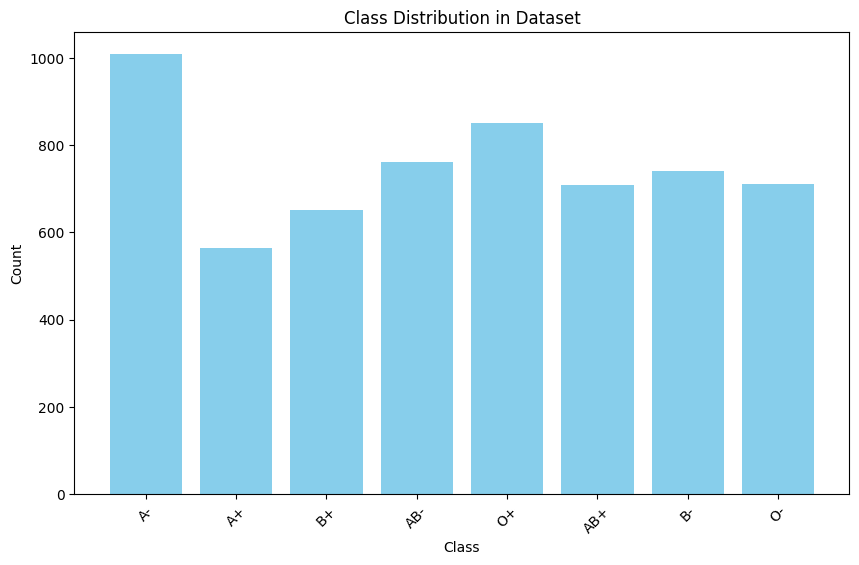

In [9]:
# Call the function to plot the distribution
plot_class_distribution(class_names, class_counts)

In [10]:
max_count = max(class_counts.values())

In [11]:
#Function to oversample a class
def oversample_class(class_id, count, max_count):
    #Ensure the dataset is unbatched for filtering
    unbatched_dataset = dataset.unbatch()
    
    #Filter the dataset for the specific class
    class_dataset = unbatched_dataset.filter(lambda img, lbl: tf.equal(lbl, class_id))
    
    #Calculate the number of repetitions needed
    repeat_factor = max_count // count + (max_count% count > 0)
    
    #Repeat the dataset to match the desired count
    return class_dataset.repeat(repeat_factor).take(max_count)
    

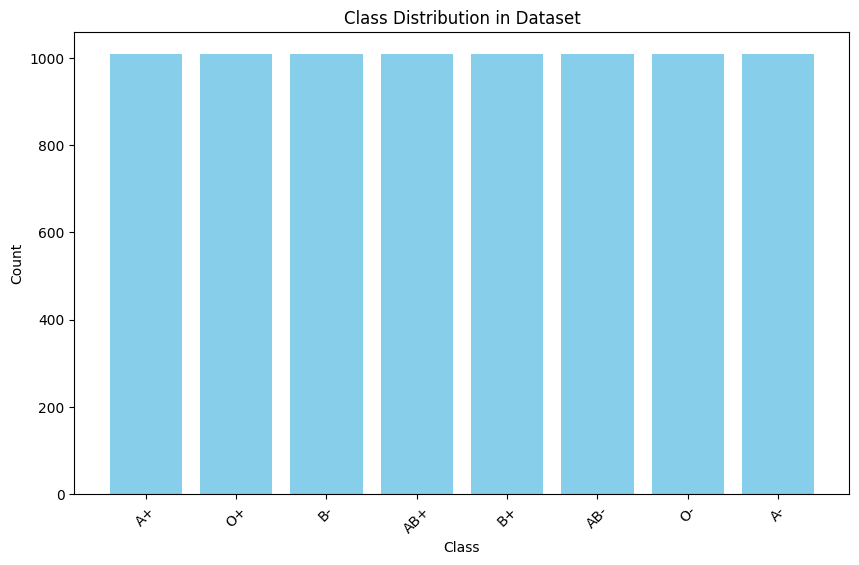

In [12]:
#Step 1: Balance the dataset
balanced_datasets = []
for class_id, count in class_counts.items():
    balanced_datasets.append(oversample_class(class_id, count, max_count))

#Step 2: Combine balanced datasets
balanced_dataset = tf.data.Dataset.sample_from_datasets (balanced_datasets)

#Step 3: Check balanced class distribution
balanced_class_counts = Counter([int(lbl.numpy()) for _, lbl in balanced_dataset])
plot_class_distribution(class_names, balanced_class_counts)

#Step 4: Batch the balanced dataset
balanced_dataset = balanced_dataset.batch(BATCH_SIZE, drop_remainder=True)

In [13]:
for sample in balanced_dataset.take(10):
    print(sample[0].shape)


(32, 32, 32, 3)
(32, 32, 32, 3)
(32, 32, 32, 3)
(32, 32, 32, 3)
(32, 32, 32, 3)
(32, 32, 32, 3)
(32, 32, 32, 3)
(32, 32, 32, 3)
(32, 32, 32, 3)
(32, 32, 32, 3)


In [14]:
balanced_dataset_unbatched = balanced_dataset.unbatch()
dataset_size = sum(1 for _ in balanced_dataset_unbatched)
print(f"Total dataset size: {dataset_size}")


Total dataset size: 8064


In [15]:
train_ratio = 0.7
val_ratio = 0.2

In [16]:
#Unbatch the dataset to work at the sample level
balanced_dataset_unbatched = balanced_dataset.unbatch()

#Compute sizes based on dataset size and desired splits
train_size = int(train_ratio * dataset_size)
val_size = int(val_ratio * dataset_size)

#Split the dataset into training, validation, and test
train_dataset = balanced_dataset_unbatched.take(train_size)
val_test_dataset = balanced_dataset_unbatched.skip(train_size)
val_dataset = val_test_dataset.take(val_size)
test_dataset =val_test_dataset.skip(val_size)

#Rebatch the datasets after splitting
train_dataset= train_dataset.batch(BATCH_SIZE, drop_remainder =True)
val_dataset= val_dataset.batch(BATCH_SIZE, drop_remainder = True)
test_dataset= test_dataset.batch(BATCH_SIZE, drop_remainder = True)

# Check the number of batches in each dataset
train_batch_count = sum(1 for _ in train_dataset)
val_batch_count = sum(1 for _ in val_dataset)
test_batch_count = sum (1 for _ in test_dataset)



print(f"Training dataset size: {train_batch_count * BATCH_SIZE}")
print(f"Validation dataset size: {val_batch_count * BATCH_SIZE}")
print(f"testing dataset size: {test_batch_count * BATCH_SIZE}")


Training dataset size: 5632
Validation dataset size: 1600
testing dataset size: 800


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

# Define number of output classes
num_classes = 8  # Replace with the actual number of classes in your dataset

def create_high_accuracy_model():
    model = Sequential([
        Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(32, 32, 3)),
        AveragePooling2D(pool_size=(2, 2)),
        Conv2D(16, kernel_size=(5, 5), activation='relu'),
        AveragePooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(120, activation='relu'),
        Dense(84, activation='relu'),
        Dense(num_classes, activation='softmax')  # Fixed
    ])
    model.compile(optimizer='adam',  # Fixed
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the model
high_acc_model = create_high_accuracy_model()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

#Define ReduceLROnPlateau callback to reduce learning rate when validation less plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose =1,
    min_lr=1e-6,
)

#Define EarlyStopping callback to stop training when validation loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',              #Monitor validation loss
    patience=5,                        #Stop after 5 epochs without Improvement
    verbose =1,
    restore_best_weights=True,         #Restore the model weights from the best epoch
)


In [19]:
#Train the model

history_high_acc = high_acc_model.fit(
    train_dataset, 
    validation_data=val_dataset,
    epochs= 25, #Adjust the number of epochs based on your preference
    callbacks = [reduce_lr, early_stop]
)

Epoch 1/25
    176/Unknown 14s 71ms/step - accuracy: 0.2035 - loss: 7.2187

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


176/176 ━━━━━━━━━━━━━━━━━━━━ 31s 168ms/step - accuracy: 0.2041 - loss: 7.1942 - val_accuracy: 0.4804 - val_loss: 1.3470 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 155ms/step - accuracy: 0.5688 - loss: 1.1812 - val_accuracy: 0.6605 - val_loss: 0.8964 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 153ms/step - accuracy: 0.6768 - loss: 0.8911 - val_accuracy: 0.6887 - val_loss: 0.8419 - learning_rate: 0.0010
Epoch 4/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.7304 - loss: 0.7423 - val_accuracy: 0.6924 - val_loss: 0.8012 - learning_rate: 0.0010
Epoch 5/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 154ms/step - accuracy: 0.7674 - loss: 0.6365 - val_accuracy: 0.7733 - val_loss: 0.5870 - learning_rate: 0.0010
Epoch 6/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 153ms/step - accuracy: 0.8079 - loss: 0.5512 - val_accuracy: 0.7880 - val_loss: 0.5516 - learning_rate: 0.0010
Epoch 7/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.8245 - loss:

In [20]:
#Evaluate the model on validation data 

high_acc_eval= high_acc_model.evaluate(val_dataset)
print(f"High Accuracy Model Loss: {high_acc_eval[0]}, Accuracy: {high_acc_eval[1]}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - accuracy: 0.9528 - loss: 0.2601
High Accuracy Model Loss: 0.2839735746383667, Accuracy: 0.9276960492134094


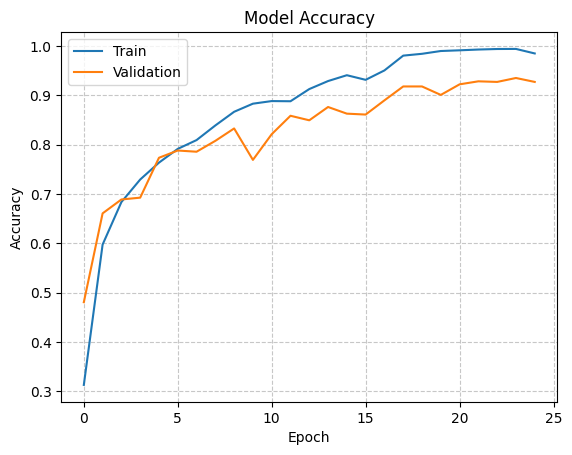

In [30]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
def plot_accuracy(history):

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

#Call the function to display the accuracy graph
plot_accuracy(history_high_acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Classification Report:
              precision    

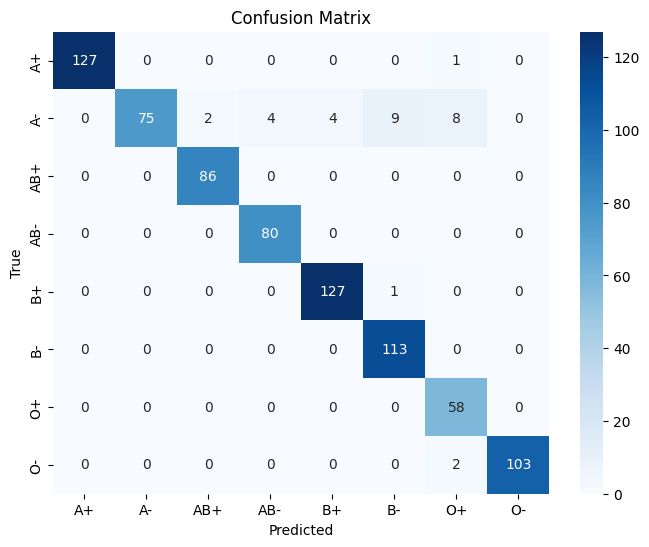

In [22]:
##Up Fix

# Get predictions on the test dataset

y_true = []  # True labels
y_pred = []  # Predicted labels

# Iterate over the test dataset and collect the true and predicted labels
for images, labels in test_dataset:  # Fixed typo (inages → images)

    predictions = high_acc_model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)  # Fixed axis-1 → axis=1
    y_true.extend(labels.numpy())  # Convert tensor to numpy array and append
    y_pred.extend(predicted_labels)  # Append the predicted labels

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:")
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Classification Report:
              precision    

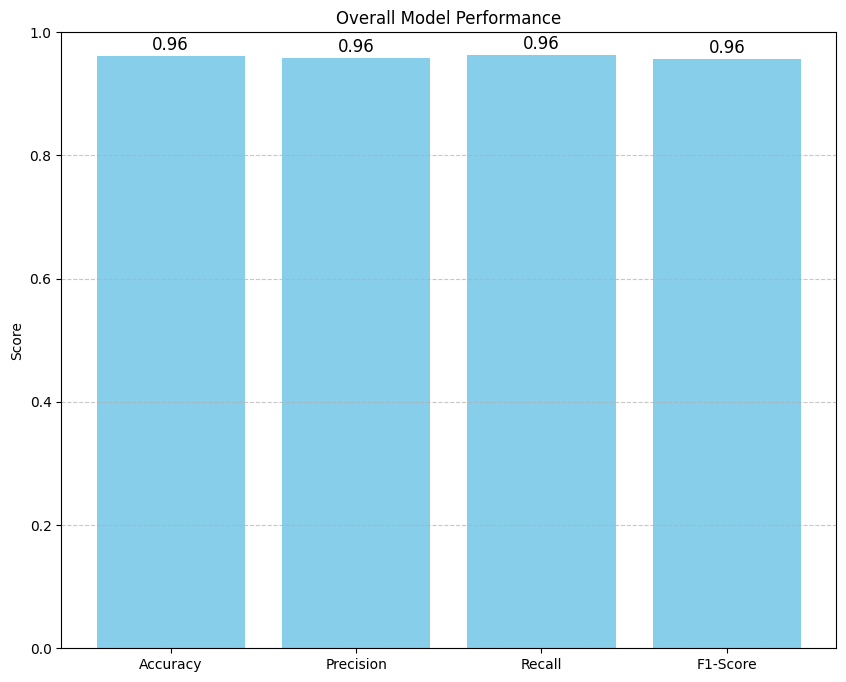

In [28]:
# Get predictions on the test dataset
y_true = []  # True labels
y_pred = []  # Predicted labels

# Iterate over the test dataset and collect the true and predicted labels
for images, labels in test_dataset:
    predictions = high_acc_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)  
    y_true.extend(labels.numpy())  
    y_pred.extend(predicted_labels)  

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate classification report
report = classification_report(y_true, y_pred, output_dict=True)
print("Classification Report:")
print(classification_report(y_true, y_pred))

# Extract overall metrics
accuracy = report['accuracy']
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']
f1_score = report['macro avg']['f1-score']

# Metrics list for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1_score]

# Plot overall performance
plt.figure(figsize=(10, 8))
plt.bar(metrics, values, color='skyblue')

plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Overall Model Performance')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the values on top of the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=12)

plt.show()


In [31]:
high_acc_model.save('model.h5') # The model will be saved as 'my model.h5'
print("Model saved as HDF5 format.")


Model saved as HDF5 format.


In [32]:
pip show pillow

Name: pillow
Version: 11.0.0
Summary: Python Imaging Library (Fork)
Home-page: https://python-pillow.org
Author: 
Author-email: "Jeffrey A. Clark" <aclark@aclark.net>
License: MIT-CMU
Location: /usr/local/lib/python3.10/dist-packages
Requires: 
Required-by: bokeh, diffusers, dopamine_rl, easyocr, fastai, fury, google-genai, ImageHash, imageio, imgaug, ipympl, matplotlib, openslide-python, pdf2image, pytesseract, scikit-image, sentence-transformers, torchtune, torchvision, wordcloud
Note: you may need to restart the kernel to use updated packages.
